In [1]:
from pathlib import Path

pth_ply = Path('results/voxel-man-default-no-normalize/ply')
pth_labels = Path('data/numpy/labels.npy')

# Инспектор ply (читает заголовок)

In [2]:
import os

def inspect_ply(file_path):
    """
    Читает заголовок PLY-файла и выводит сводку: 
    формат, количество элементов и их поля.
    """
    if not os.path.exists(file_path):
        print(f"Ошибка: Файл '{file_path}' не найден.")
        return

    header_lines = []
    
    # Читаем только заголовок до слова end_header
    with open(file_path, 'rb') as f:
        for line in f:
            line_str = line.decode('ascii', errors='ignore').strip()
            header_lines.append(line_str)
            if line_str == 'end_header':
                break

    # Парсинг собранных строк
    print(f"\n{'='*40}")
    print(f"ФАЙЛ: {os.path.basename(file_path)}")
    
    elements = []
    current_element = None

    for line in header_lines:
        parts = line.split()
        if not parts: continue

        if parts[0] == 'format':
            print(f"ФОРМАТ: {' '.join(parts[1:])}")
        
        elif parts[0] == 'element':
            name, count = parts[1], parts[2]
            current_element = {'name': name, 'count': count, 'props': []}
            elements.append(current_element)
        
        elif parts[0] == 'property':
            if current_element is not None:
                # Если это список (например, для граней), берем последнее слово
                # Если обычное поле (x, y, red), тоже берем последнее слово
                prop_name = parts[-1]
                prop_type = parts[1] if parts[1] != 'list' else f"list({parts[2]})"
                current_element['props'].append(f"{prop_name} ({prop_type})")

    # Красивый вывод результата
    print(f"{'='*40}")
    for el in elements:
        print(f"Элемент '{el['name']}':")
        print(f"Количество: {el['count']}")
        print(f"Поля: \t{'\n\t'.join(el['props'])}")

# Чтение данных из ply вместе с именами полей

In [3]:
import numpy as np
from plyfile import PlyData

def get_ply_data(file_path):
    ply = PlyData.read(file_path)
    # гауссианы записываются как vertex
    el = ply['vertex']
    
    field_names = [prop.name for prop in el.properties]
    # все параметры гауссиан по стандарту записаны как f4
    data = np.stack([el[name] for name in field_names], axis=1).astype(np.float32)
    
    return data, field_names

# Запись ply с новым полем - сегментацией (формата u4)

In [34]:
import numpy as np
from plyfile import PlyData, PlyElement

def save_ply_with_segmentation(file_path, points, fields, seg_data):
    dtype = [(name, 'f4') for name in fields]
    dtype.append(('segmentation', 'u4'))
    
    n_points = points.shape[0]
    seg_points = np.empty(n_points, dtype=dtype)
    
    for i, name in enumerate(fields):
        seg_points[name] = points[:, i]
    
    seg_points['segmentation'] = seg_data
    
    el = PlyElement.describe(seg_points, 'vertex')
    PlyData([el], text=False).write(file_path)

# Вспомогательный код трансформации из processing_scripts/numpy_to_points3Dbin.py для согласованности обучающих гауссиан и сегментированных

In [38]:
# тут согласованные ранее метки костной системы из
# voxel-man-to-numpy.ipynb

bones_ids = [
    # General
    6501,

    # Clavicles and sternum
    6502, 6503, 6504,

    # Cervical vertebrae
    6511, 6512, 6513,

    # Thoracic vertebrae
    6514, 6515, 6516, 6517, 6518,
    6519, 6520, 6521, 6522, 6523,
    6524, 6554,

    # Ribs
    6525, 6526,
    6527, 6528,
    6529, 6530,
    6531, 6532,
    6533, 6534,
    6535, 6536,
    6537, 6538,
    6539, 6540,
    6541, 6542,
    6543, 6544,
    6550, 6551,
    6552, 6553,

    # Upper limbs
    6546, 6547,   # humerus
    6566, 6567,   # right radius/ulna
    6568, 6569,   # left radius/ulna
    6570, 6571,   # hand bones

    # Scapulae
    6548, 6549,

    # Lumbar spine
    6555, 6556, 6557, 6558, 6559,

    # Pelvis and lower spine
    6560, 6561,
    6562, 6563,

    # Femurs
    6564, 6565
]

cartilage_ids = [
    7013,
    7036,
    7037, 7038, 7039, 7040, 7041, 7042,
    7044,
    7045, 7046, 7047, 7048, 7049, 7050
]

intervertebral_disc_ids = [
    7015, 7016, 7017, 7018, 7019,
    7020, 7021, 7022, 7023, 7024,
    7025, 7026, 7027, 7028, 7029,
    7030, 7031, 7032, 7033, 7034
]

skeletal_system_ids = (
    bones_ids +
    cartilage_ids +
    intervertebral_disc_ids
)

In [97]:
import numpy as np

def transform_3d(
    labels, num_choice=100_000,
    # дефолтные преобразования сразу подставлены согласовано со скриптом 
    # processing_scripts/numpy_to_points3Dbin.py
    # кроме translate который вычисляется относительно
    s=np.array([0.1, 0.1, 0.1]), r=np.array([180, 0, 0]),
):
    '''
        input: labels (X, Y, Z)
        output: coords (N, 3) и labels (N,)
    '''
    t = np.array([-0.5, 0.5, 0.5]) * labels.shape * s
    
    mask = np.isin(labels, skeletal_system_ids)
    coords = np.argwhere(mask)
    labels = labels[mask]

    idx = np.random.choice(coords.shape[0], num_choice, replace=False)
    coords = coords[idx] # (N, 3)
    labels = labels[idx]
    
    xyz = np.vstack((coords.T, np.ones(num_choice))) # (4, N)
    
    S = np.diag([*s, 1])

    Rx, Ry, Rz = np.eye(4), np.eye(4), np.eye(4)
    theta_x, theta_y, theta_z = np.radians(r)
    
    Rx[:3, :3] = np.array([
        [1, 0,                0              ],
        [0, np.cos(theta_x), -np.sin(theta_x)],
        [0, np.sin(theta_x),  np.cos(theta_x)],
    ])
    
    Ry[:3, :3] = np.array([
        [ np.cos(theta_y), 0, np.sin(theta_y)],
        [ 0,               1, 0              ],
        [-np.sin(theta_y), 0, np.cos(theta_y)],
    ])

    Rz[:3, :3] = np.array([
        [np.cos(theta_z), -np.sin(theta_z), 0],
        [np.sin(theta_z),  np.cos(theta_z), 0],
        [0,                0,               1],
    ])

    R = Rx @ Ry @ Rz
    
    T = np.eye(4)
    T[:3, 3] = t

    M = T @ R @ S
    xyz = M @ xyz # (4, N)
    coords = xyz[:3, :].T # (N, 3)
    
    return coords.astype(np.float32), labels

# Сегментируем данные по принципу ближайшего соседа по исходной разметке

In [107]:
inspected_ply = pth_ply / 'point_cloud_29999.ply'
segmented_ply = pth_ply / 'segmented.ply'

# загружает обученные гауссианы
inspect_ply(inspected_ply)
points, fields = get_ply_data(inspected_ply)

# загружаем 1_000_000 случайных меток и трансформируем их в соответствии с colmap
labels = np.load(pth_labels)
coords, labels = transform_3d(labels, 1_000_000)


ФАЙЛ: point_cloud_29999.ply
ФОРМАТ: binary_little_endian 1.0
Элемент 'vertex':
Количество: 318861
Поля: 	x (float)
	y (float)
	z (float)
	f_dc_0 (float)
	f_dc_1 (float)
	f_dc_2 (float)
	f_rest_0 (float)
	f_rest_1 (float)
	f_rest_2 (float)
	f_rest_3 (float)
	f_rest_4 (float)
	f_rest_5 (float)
	f_rest_6 (float)
	f_rest_7 (float)
	f_rest_8 (float)
	f_rest_9 (float)
	f_rest_10 (float)
	f_rest_11 (float)
	f_rest_12 (float)
	f_rest_13 (float)
	f_rest_14 (float)
	f_rest_15 (float)
	f_rest_16 (float)
	f_rest_17 (float)
	f_rest_18 (float)
	f_rest_19 (float)
	f_rest_20 (float)
	f_rest_21 (float)
	f_rest_22 (float)
	f_rest_23 (float)
	f_rest_24 (float)
	f_rest_25 (float)
	f_rest_26 (float)
	f_rest_27 (float)
	f_rest_28 (float)
	f_rest_29 (float)
	f_rest_30 (float)
	f_rest_31 (float)
	f_rest_32 (float)
	f_rest_33 (float)
	f_rest_34 (float)
	f_rest_35 (float)
	f_rest_36 (float)
	f_rest_37 (float)
	f_rest_38 (float)
	f_rest_39 (float)
	f_rest_40 (float)
	f_rest_41 (float)
	f_rest_42 (float)
	f_rest

In [110]:
import numpy as np
from scipy.spatial import cKDTree

def transfer_segmentation_kdtree(target_points, source_coords, source_labels, k=1, workers=-1):
    tree = cKDTree(source_coords)
    distances, indices = tree.query(target_points, k=1, workers=workers)
    target_labels = source_labels[indices]

    # визуализация distances чтобы быть уверенным что всё нормально приклеелось
    plt.figure(figsize=(10, 6))
    
    n, bins, patches = plt.hist(distances, bins=100, color='skyblue', edgecolor='black', log=True)
    plt.axvline(np.mean(distances), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(distances):.2f}')
    plt.axvline(np.median(distances), color='green', linestyle='dashed', linewidth=2, label=f'Median: {np.median(distances):.2f}')
    
    plt.title('Распределение расстояний от Гауссиан до ближайшего вокселя')
    plt.xlabel('Евклидово расстояние')
    plt.ylabel('Количество точек (логарифмическая шкала)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    return target_labels

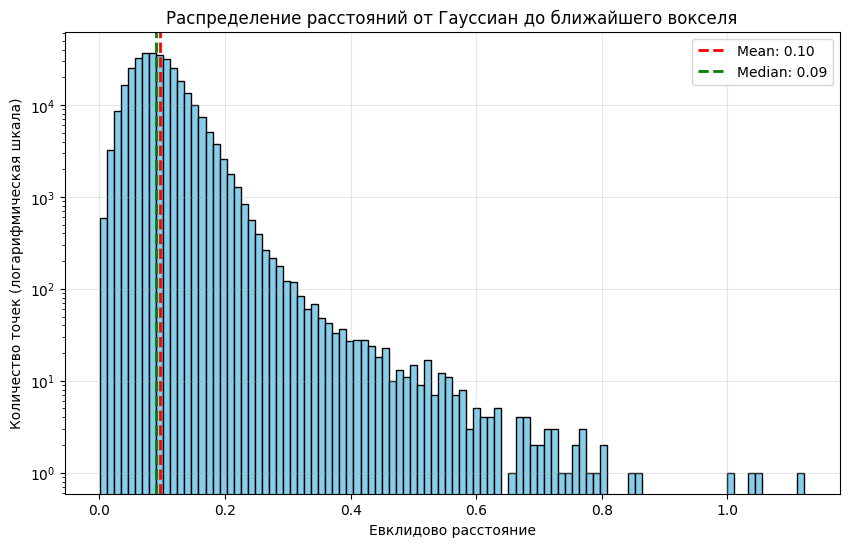

In [111]:
target_labels = transfer_segmentation_kdtree(points[:, :3], coords, labels)

save_ply_with_segmentation(
    segmented_ply, 
    points, 
    fields, 
    target_labels,
)

In [112]:
inspect_ply(segmented_ply)


ФАЙЛ: segmented.ply
ФОРМАТ: binary_little_endian 1.0
Элемент 'vertex':
Количество: 318861
Поля: 	x (float)
	y (float)
	z (float)
	f_dc_0 (float)
	f_dc_1 (float)
	f_dc_2 (float)
	f_rest_0 (float)
	f_rest_1 (float)
	f_rest_2 (float)
	f_rest_3 (float)
	f_rest_4 (float)
	f_rest_5 (float)
	f_rest_6 (float)
	f_rest_7 (float)
	f_rest_8 (float)
	f_rest_9 (float)
	f_rest_10 (float)
	f_rest_11 (float)
	f_rest_12 (float)
	f_rest_13 (float)
	f_rest_14 (float)
	f_rest_15 (float)
	f_rest_16 (float)
	f_rest_17 (float)
	f_rest_18 (float)
	f_rest_19 (float)
	f_rest_20 (float)
	f_rest_21 (float)
	f_rest_22 (float)
	f_rest_23 (float)
	f_rest_24 (float)
	f_rest_25 (float)
	f_rest_26 (float)
	f_rest_27 (float)
	f_rest_28 (float)
	f_rest_29 (float)
	f_rest_30 (float)
	f_rest_31 (float)
	f_rest_32 (float)
	f_rest_33 (float)
	f_rest_34 (float)
	f_rest_35 (float)
	f_rest_36 (float)
	f_rest_37 (float)
	f_rest_38 (float)
	f_rest_39 (float)
	f_rest_40 (float)
	f_rest_41 (float)
	f_rest_42 (float)
	f_rest_43 (flo

# Сохранение в сжатый формат для отображения в браузере

In [26]:
import numpy as np
from plyfile import PlyData

def process_ply_to_splat(ply_file_path, splat_file_path):
    print("Reading PLY...")
    plydata = PlyData.read(ply_file_path)
    v = plydata["vertex"]
    num_verts = v.count

    print("Calculating importance...")
    importance = np.exp(v["scale_0"] + v["scale_1"] + v["scale_2"]) / (1 + np.exp(-v["opacity"]))
    indices = np.argsort(-importance)

    dtype = [
        ('position', '<f4', 3),
        ('scales', '<f4', 3),
        ('color', '<u1', 4),
        ('rotation', '<u1', 4),
        ('segmentation', '<u4')
    ]
    
    splat_data = np.empty(num_verts, dtype=dtype)

    print("Filling data...")
    
    # Позиции
    splat_data['position'][:, 0] = v['x']
    splat_data['position'][:, 1] = v['y']
    splat_data['position'][:, 2] = v['z']

    # Масштабы (экспоненцированные)
    splat_data['scales'][:, 0] = np.exp(v['scale_0'])
    splat_data['scales'][:, 1] = np.exp(v['scale_1'])
    splat_data['scales'][:, 2] = np.exp(v['scale_2'])

    # Цвета (SH -> RGB + Opacity)
    SH_C0 = 0.28209479177387814
    r = (0.5 + SH_C0 * v['f_dc_0']) * 255
    g = (0.5 + SH_C0 * v['f_dc_1']) * 255
    b = (0.5 + SH_C0 * v['f_dc_2']) * 255
    a = (1 / (1 + np.exp(-v['opacity']))) * 255
    
    splat_data['color'][:, 0] = np.clip(r, 0, 255)
    splat_data['color'][:, 1] = np.clip(g, 0, 255)
    splat_data['color'][:, 2] = np.clip(b, 0, 255)
    splat_data['color'][:, 3] = np.clip(a, 0, 255)

    # Вращение (Нормализация кватернионов)
    rots = np.stack([v['rot_0'], v['rot_1'], v['rot_2'], v['rot_3']], axis=-1)
    qlen = np.linalg.norm(rots, axis=-1, keepdims=True)
    # Обрабатываем деление на ноль, если вдруг есть пустые кватернионы
    qlen[qlen == 0] = 1.0
    rots_norm = (rots / qlen) * 128 + 128
    
    splat_data['rotation'][:, 0] = np.clip(rots_norm[:, 0], 0, 255)
    splat_data['rotation'][:, 1] = np.clip(rots_norm[:, 1], 0, 255)
    splat_data['rotation'][:, 2] = np.clip(rots_norm[:, 2], 0, 255)
    splat_data['rotation'][:, 3] = np.clip(rots_norm[:, 3], 0, 255)

    # Сегментация
    splat_data['segmentation'] = v['segmentation'].astype(np.uint32)
    return splat_data['segmentation']

    print("Sorting...")
    splat_data = splat_data[indices]

    print(f"Saving to {splat_file_path}...")
    #with open(splat_file_path, "wb") as f:
    #    f.write(splat_data.tobytes())
    
    print("Done!")

In [27]:
data = process_ply_to_splat(pth_ply / 'segmented.ply', Path("splat/segmented.splat"))

Reading PLY...
Calculating importance...
Filling data...


In [31]:
ply = PlyData.read(pth_ply / 'segmented.ply')

In [34]:
ply['vertex']['segmentation'].min()

6501